In [6]:
# pandas for data manipulation
# re for regular expressions
import re

# graph helpers
import numpy as np
import pandas as pd

# Use the importable implementation so multi-core workers work from notebooks on Windows.
from utils.csi_processing import process_standard_files as process_files
from utils.feature_pipeline import build_frequency_feature_dataframes
from utils.graphs import plot_magnitude_analysis_interactive
from utils.import_data import get_csv_files, print_user_location_tables, sort_meta_info

In [7]:
path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\CSI DATA"

# scenario -> location -> user -> esp -> trial -> file_path
FileMap = dict[str, dict[str, dict[str, dict[str, dict[str, str]]]]]
# scenario -> location -> user -> esp -> trial -> csi ndarray
csi_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]
# scenario -> location -> user -> esp -> trial -> agc gain ndarray
agc_gain_map = dict[str, dict[str, dict[str, dict[str, dict[str, np.ndarray]]]]]


all_data_files = get_csv_files(path)
scenarios_id, locations_id, users_id, esps_id, trials_id = sort_meta_info(path)

print(f"Scenarios present: {', '.join(scenarios_id) or 'none'}")
print_user_location_tables(all_data_files)


Scenarios present: 1

User 01 - Pedro Monteiro
    1  2  3  4  5  6  7  8  9 10 11 12 13 14
A | .  .  .  .  .  .  .  .  .  .  .  .  .  .
B | .  .  .  .  .  .  .  .  .  .  .  .  .  .
C | .  .  .  .  .  .  .  .  .  .  .  .  .  .
D | .  .  .  .  .  .  .  .  .  .  .  .  .  .
E | .  .  .  .  .  .  .  .  .  .  .  .  .  .
F | .  .  .  .  .  .  .  .  .  .  .  .  .  .
No files found for this user.

User 02 - Guilherme Cabaço
    1  2  3  4  5  6  7  8  9 10 11 12 13 14
A | X  X  .  .  X  .  .  .  .  .  .  .  X  X
B | X  X  .  .  X  .  .  .  .  X  X  X  X  X
C | X  X  X  X  X  X  X  X  X  X  X  .  .  X
D | X  X  X  X  X  X  X  X  .  .  .  .  .  .
E | X  X  X  X  X  X  X  X  .  X  X  X  X  .
F | .  .  .  .  X  .  .  X  .  X  X  X  X  .
Other locations: Z-0

User 03 - Henrique
    1  2  3  4  5  6  7  8  9 10 11 12 13 14
A | X  X  .  .  X  .  .  .  .  .  .  .  X  X
B | X  X  .  .  X  .  .  X  .  X  X  X  X  X
C | X  X  X  X  X  X  X  X  X  X  X  .  .  X
D | X  X  X  X  X  X  X  X  .  .  .  .  .  .

In [8]:
magnitude_data, agc_gain_data = process_files(all_data_files)

In [9]:
# Asks what graph subset to draw before plotting.
# Increase packet_stride_3d if the 3D plots are slow to render.
#plot_magnitude_analysis_interactive(magnitude_data)

### Pre Processing

In [10]:
WINDOW_SIZE = 60
OVERLAP_SIZE = 30

# calibrate
# # whether to apply normalization to the magnitude data before extracting features.

# require_all_esps
# # whether to only include trials that have data for all ESPs in the
# frequency scenario when building the feature dataframes.
# If False, trials with missing ESPs will still be included
# but will have NaN values for the features of the missing ESPs.

df_24ghz, df_5ghz, df_fusion = build_frequency_feature_dataframes(
    magnitude_data,
    window_size=WINDOW_SIZE,
    overlap_size=OVERLAP_SIZE,
    calibrate=False,
    require_all_esps=True,
)

feature_dataframes = {
    "2.4 GHz": df_24ghz,
    "5 GHz": df_5ghz,
    "Fusion": df_fusion,
}

In [11]:
feature_dataframe_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "rows": dataframe.shape[0],
            "columns": dataframe.shape[1],
            "groups": dataframe["group_id"].nunique() if not dataframe.empty else 0,
            "labels": (
                dict(dataframe["label"].value_counts().sort_index())
                if not dataframe.empty
                else {}
            ),
        }
        for dataset_name, dataframe in feature_dataframes.items()
    ],
)
feature_dataframe_summary

,dataset,rows,columns,groups,labels
0,2.4 GHz,2725,3008,49,"{0: 63, 1: 1629, 2: 548, 3: 485}"
1,5 GHz,2527,3368,105,"{0: 63, 1: 1559, 2: 498, 3: 407}"
2,Fusion,1111,6368,49,"{0: 39, 1: 642, 2: 244, 3: 186}"


### Random Forest Models

Random and group-aware train/test splits for each feature dataframe.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
TEST_SIZE = 0.20
MIN_STRATIFIED_CLASS_COUNT = 2
MIN_GROUP_SPLIT_COUNT = 2
NON_FEATURE_COLUMNS = {
    "frequency_scenario",
    "scenario",
    "location",
    "user",
    "trial",
    "group_id",
    "window_idx",
    "label",
}
RANDOM_FOREST_PARAMS = {
    "n_estimators": 300,
    "max_features": "sqrt",
    "class_weight": "balanced",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}


# Prepares the feature matrix, label vector, and group identifiers for modeling.
def _model_inputs(dataframe: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series]:
    feature_columns = [column for column in dataframe.columns if column not in NON_FEATURE_COLUMNS]
    return dataframe[feature_columns], dataframe["label"].astype(int), dataframe["group_id"]


# Returns a dictionary mapping split names to tuples of (train_indices, test_indices).
def _split_indices(dataframe: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    features, y, groups = _model_inputs(dataframe)
    row_indices = np.arange(len(dataframe))
    stratify_labels = y if y.value_counts().min() >= MIN_STRATIFIED_CLASS_COUNT else None
    random_train_idx, random_test_idx = train_test_split(
        row_indices,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=stratify_labels,
    )

    if groups.nunique() < MIN_GROUP_SPLIT_COUNT:
        msg = "Group split requires at least two unique group_id values."
        raise ValueError(msg)

    group_splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )
    group_train_idx, group_test_idx = next(group_splitter.split(features, y, groups))

    return {
        "random": (random_train_idx, random_test_idx),
        "group": (group_train_idx, group_test_idx),
    }


# Fits a Random Forest model on the training data and evaluates it on the test data,
# returning the results and metrics.
def _fit_and_evaluate_random_forest(
    dataset_name: str,
    split_name: str,
    dataframe: pd.DataFrame,
    train_idx: np.ndarray,
    test_idx: np.ndarray,
) -> tuple[dict[str, object], pd.DataFrame, pd.DataFrame, object]:
    features, y, groups = _model_inputs(dataframe)
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        RandomForestClassifier(**RANDOM_FOREST_PARAMS),
    )

    features_train = features.iloc[train_idx]
    features_test = features.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    model.fit(features_train, y_train)
    y_pred = model.predict(features_test)

    labels = sorted(y.unique())
    report = pd.DataFrame(
        classification_report(
            y_test,
            y_pred,
            labels=labels,
            output_dict=True,
            zero_division=0,
        ),
    ).transpose()
    matrix = pd.DataFrame(
        confusion_matrix(y_test, y_pred, labels=labels),
        index=pd.Index(labels, name="actual"),
        columns=pd.Index(labels, name="predicted"),
    )

    result = {
        "dataset": dataset_name,
        "split": split_name,
        "train_rows": len(train_idx),
        "test_rows": len(test_idx),
        "train_groups": groups.iloc[train_idx].nunique(),
        "test_groups": groups.iloc[test_idx].nunique(),
        "train_label_counts": dict(y_train.value_counts().sort_index()),
        "test_label_counts": dict(y_test.value_counts().sort_index()),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "precision_macro": precision_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "precision_weighted": precision_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "recall_weighted": recall_score(
            y_test,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
        "f1_weighted": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }
    return result, report, matrix, model


rf_result_rows = []
rf_classification_reports = {}
rf_confusion_matrices = {}
rf_models = {}
rf_split_indices = {}

# Iterate over each dataset and split, fit the Random Forest model, and store the results.
for dataset_name, dataframe in feature_dataframes.items():
    if dataframe.empty:
        continue

    for split_name, (train_idx, test_idx) in _split_indices(dataframe).items():
        model_key = (dataset_name, split_name)
        rf_split_indices[model_key] = {
            "train_idx": train_idx,
            "test_idx": test_idx,
        }
        result, report, matrix, model = _fit_and_evaluate_random_forest(
            dataset_name,
            split_name,
            dataframe,
            train_idx,
            test_idx,
        )
        rf_result_rows.append(result)
        rf_classification_reports[model_key] = report
        rf_confusion_matrices[model_key] = matrix
        rf_models[model_key] = model

random_forest_results = pd.DataFrame(rf_result_rows).sort_values(["dataset", "split"])
random_forest_results

,dataset,split,train_rows,test_rows,train_groups,test_groups,train_label_counts,test_label_counts,accuracy,balanced_accuracy,f1_macro,f1_weighted
1,2.4 GHz,group,2154,571,39,10,"{0: 63, 1: 1296, 2: 491, 3: 304}","{1: 333, 2: 57, 3: 181}",1.000000,1.000000,1.000000,1.000000
0,2.4 GHz,random,2180,545,49,49,"{0: 51, 1: 1303, 2: 438, 3: 388}","{0: 12, 1: 326, 2: 110, 3: 97}",0.998165,0.979167,0.987848,0.998130
3,5 GHz,group,2006,521,84,21,"{0: 39, 1: 1260, 2: 347, 3: 360}","{0: 24, 1: 299, 2: 151, 3: 47}",0.907869,0.706601,0.642857,0.898163
2,5 GHz,random,2021,506,105,104,"{0: 50, 1: 1247, 2: 398, 3: 326}","{0: 13, 1: 312, 2: 100, 3: 81}",1.000000,1.000000,1.000000,1.000000
5,Fusion,group,854,257,39,10,"{0: 39, 1: 488, 2: 210, 3: 117}","{1: 154, 2: 34, 3: 69}",0.992218,0.995671,0.988298,0.992304
4,Fusion,random,888,223,49,48,"{0: 31, 1: 513, 2: 195, 3: 149}","{0: 8, 1: 129, 2: 49, 3: 37}",1.000000,1.000000,1.000000,1.000000


In [20]:
SELECTED_RF_MODEL = ("2.4 GHz", "random")

display(rf_classification_reports[SELECTED_RF_MODEL])
print()

SELECTED_RF_MODEL = ("5 GHz", "random")

display(rf_classification_reports[SELECTED_RF_MODEL])
print()

SELECTED_RF_MODEL = ("Fusion", "random")

display(rf_classification_reports[SELECTED_RF_MODEL])
print()
display(rf_confusion_matrices[SELECTED_RF_MODEL])

,precision,recall,f1-score,support
0,1.000000,0.916667,0.956522,12.000000
1,1.000000,1.000000,1.000000,326.000000
2,1.000000,1.000000,1.000000,110.000000
3,0.989796,1.000000,0.994872,97.000000
accuracy,0.998165,0.998165,0.998165,0.998165
macro avg,0.997449,0.979167,0.987848,545.000000
weighted avg,0.998184,0.998165,0.998130,545.000000


,precision,recall,f1-score,support
0,1.0,1.0,1.0,13.0
1,1.0,1.0,1.0,312.0
2,1.0,1.0,1.0,100.0
3,1.0,1.0,1.0,81.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,506.0
weighted avg,1.0,1.0,1.0,506.0


,precision,recall,f1-score,support
0,1.0,1.0,1.0,8.0
1,1.0,1.0,1.0,129.0
2,1.0,1.0,1.0,49.0
3,1.0,1.0,1.0,37.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,223.0
weighted avg,1.0,1.0,1.0,223.0


predicted,0,1,2,3
actual,,,,
0,8,0,0,0
1,0,129,0,0
2,0,0,49,0
3,0,0,0,37


### Random Forest Plots

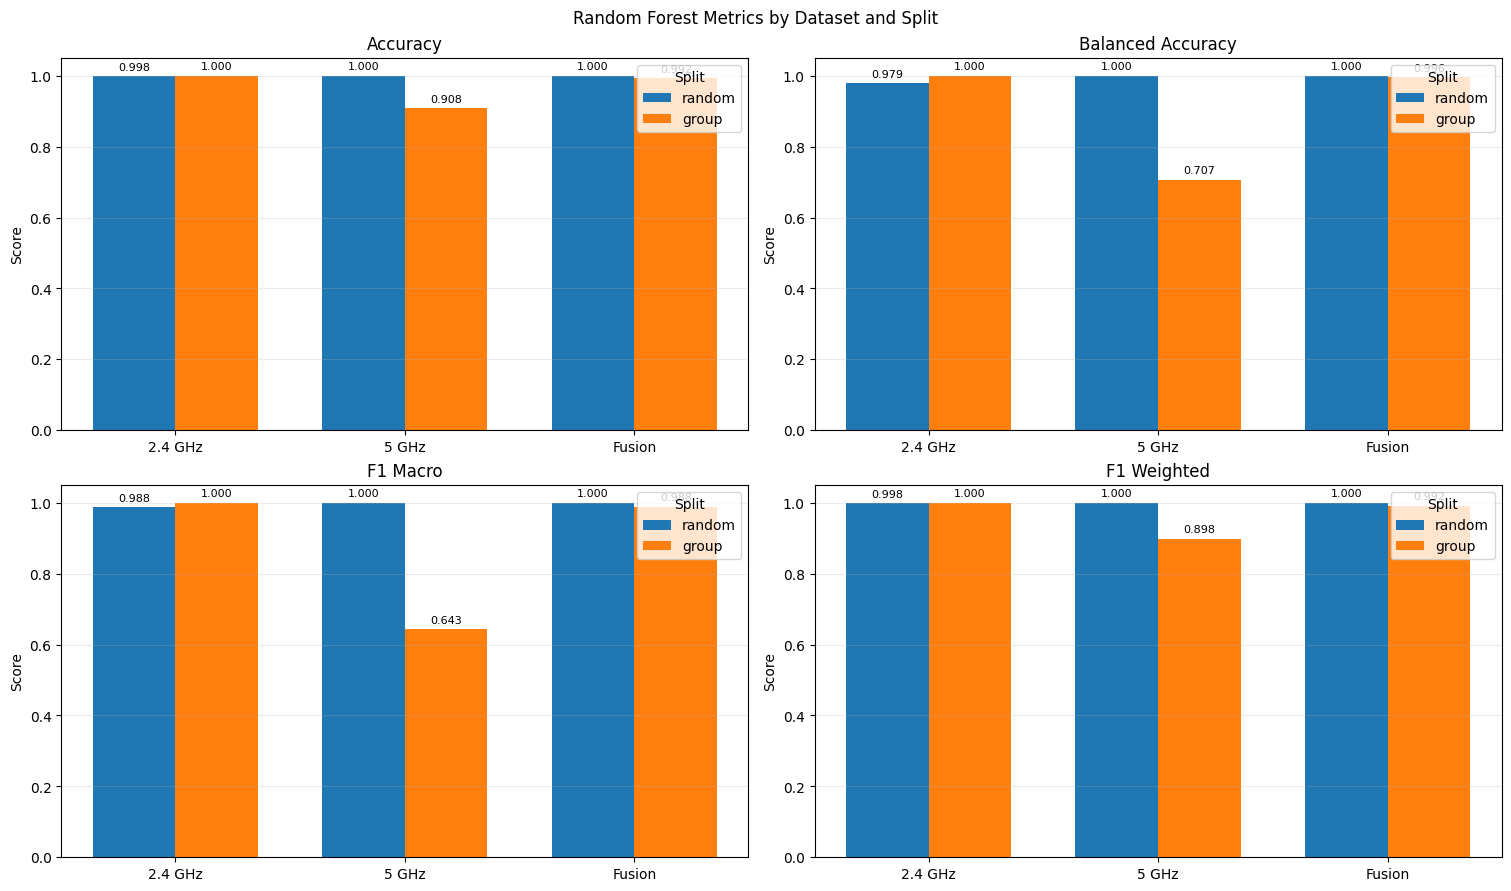

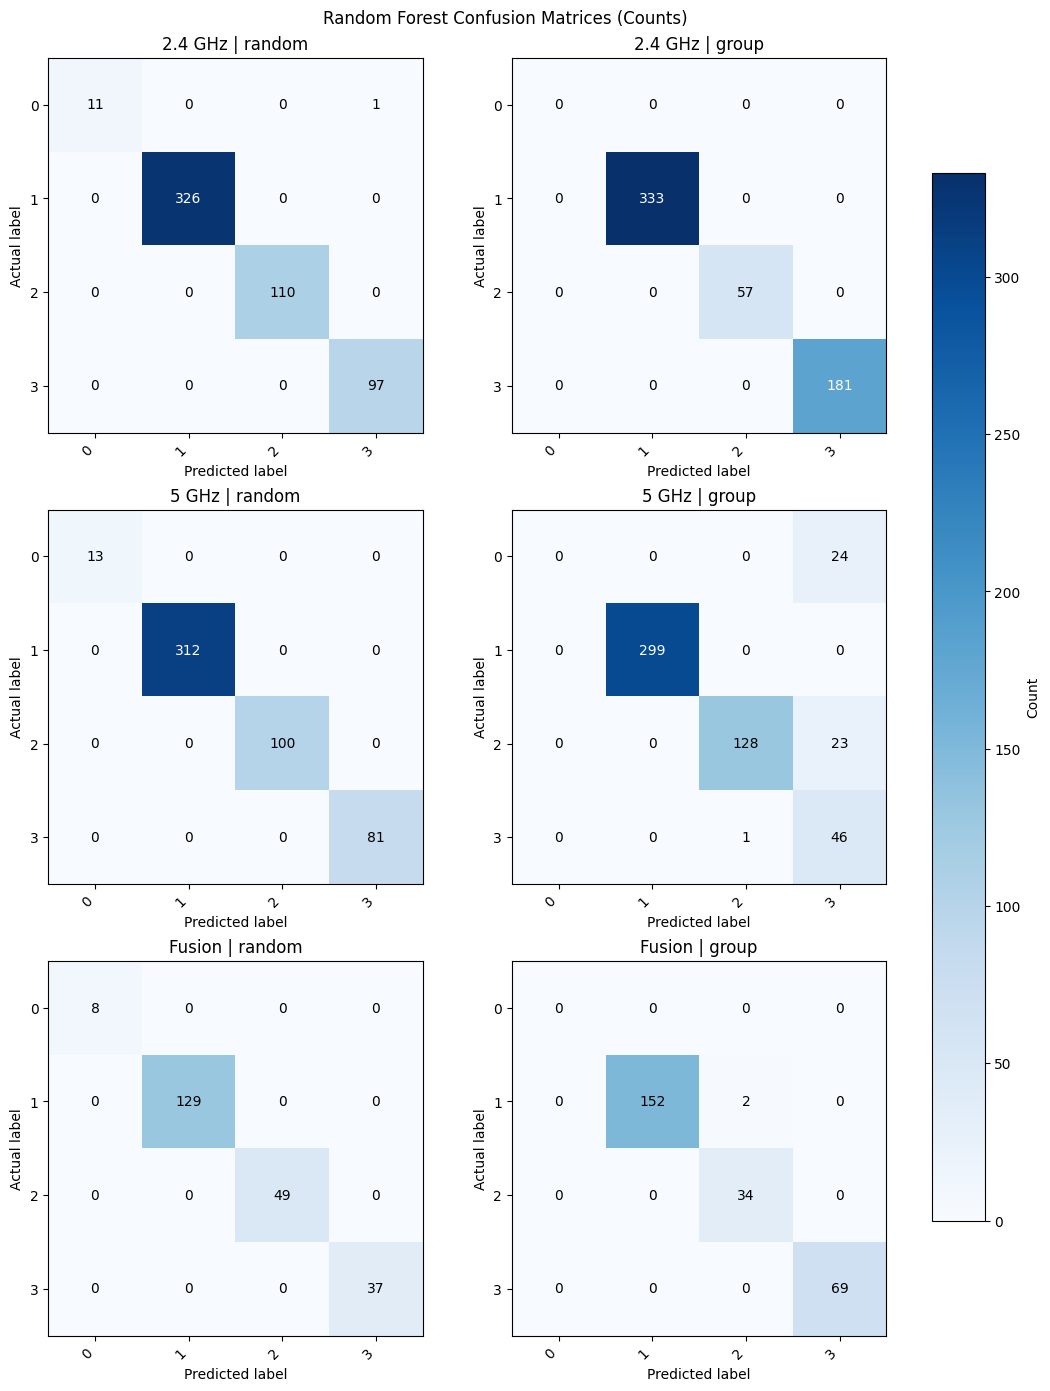

In [21]:
import importlib

from utils import graphs

importlib.reload(graphs)

graphs.plot_random_forest_metric_comparison(random_forest_results)
graphs.plot_random_forest_confusion_matrices(rf_confusion_matrices)

In [14]:
""" # Auto-run I/Q plots using provided inputs (D-5, all, specified subcarriers)
import importlib

from utils import graphs

importlib.reload(graphs)
normalize_location_input = graphs.normalize_location_input
get_available_esp_keys_for_location_files = graphs.get_available_esp_keys_for_location_files
plot_selected_iq_constellations = graphs.plot_selected_iq_constellations
location = 'D-5'
location_key = normalize_location_input(location)
if location_key is None:
    raise ValueError(f'Invalid location: {location}')
esp_keys = get_available_esp_keys_for_location_files(all_data_files, location_key)
if not esp_keys:
    print('No ESPs found for', location)
else:
    sc_indices = [10, 11, 12, 13, 14, 15, 16, 17, 18, 29, 20]
    print(f'Plotting location {location_key} ESPs {esp_keys} subcarriers {sc_indices}')
    plot_selected_iq_constellations(all_data_files, location_key, esp_keys, sc_indices=sc_indices) """

" # Auto-run I/Q plots using provided inputs (D-5, all, specified subcarriers)\nimport importlib\n\nfrom utils import graphs\n\nimportlib.reload(graphs)\nnormalize_location_input = graphs.normalize_location_input\nget_available_esp_keys_for_location_files = graphs.get_available_esp_keys_for_location_files\nplot_selected_iq_constellations = graphs.plot_selected_iq_constellations\nlocation = 'D-5'\nlocation_key = normalize_location_input(location)\nif location_key is None:\n    raise ValueError(f'Invalid location: {location}')\nesp_keys = get_available_esp_keys_for_location_files(all_data_files, location_key)\nif not esp_keys:\n    print('No ESPs found for', location)\nelse:\n    sc_indices = [10, 11, 12, 13, 14, 15, 16, 17, 18, 29, 20]\n    print(f'Plotting location {location_key} ESPs {esp_keys} subcarriers {sc_indices}')\n    plot_selected_iq_constellations(all_data_files, location_key, esp_keys, sc_indices=sc_indices) "